# Notebook 03 - Préparation des données (Preprocessing)

**Projet** : Classification des Astéroïdes Potentiellement Dangereux (PHAs)  
**Module** : Machine Learning -- ENSA Tétouan -- Pr. Yacine EL YOUNOUSSI -- 2025-2026  
**Auteurs** : Bouchennou Ferdaouss · El Allouche Zakariyae · Tafraouti Sanae

## 0. Imports et chargement commun

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})
sns.set_palette("Set2")

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path(".").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "dataset.csv"
TARGET = "is_potentially_hazardous"

print("Bibliothèques chargées.")

Bibliothèques chargées.


In [21]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Variable cible  : {TARGET}")
df.head()

Dataset chargé : 20,000 lignes × 27 colonnes
Variable cible  : is_potentially_hazardous


,absolute_magnitude_h,estimated_diameter_min_km,is_sentry_object,is_potentially_hazardous,relative_velocity_km_per_second,miss_distance_astronomical,orbiting_body,n_approaches,min_miss_distance_au,max_velocity_km_s,...,orbit_uncertainty,minimum_orbit_intersection,data_arc_in_days,orbit_class_type,diameter_mean_km,diameter_uncertainty,perihelion_to_aphelion_ratio,threat_ratio,velocity_distance_ratio,observation_reliability
0,10.39,22.210328,0,0,3.983382,0.387314,EARTH,34,0.149462,6.084052,...,0.0,0.148353,46582.0,AMO,35.937066,27.453475,0.635542,0.004128,10.284639,0.0
1,15.59,2.025606,0,0,3.752797,1.822843,JUPTR,8,1.389955,5.004842,...,0.0,0.201318,41839.0,AMO,3.277499,2.503787,0.293163,0.061424,2.058761,0.0
2,13.82,4.576727,0,0,11.268954,0.166325,EARTH,3,0.082198,11.268954,...,0.0,0.079677,39281.0,AMO,7.405299,5.657145,0.272937,0.010759,67.752490,0.0
3,9.17,38.954262,0,0,15.749851,0.028684,MARS,5,0.028684,15.749851,...,0.0,0.343339,37087.0,AMO,63.029319,48.150115,0.304450,0.005447,549.090712,0.0
4,17.37,0.892391,0,0,10.502144,0.170464,EARTH,20,0.105277,11.080933,...,0.0,0.107969,33947.0,AMO,1.443918,1.103055,0.394085,0.074775,61.609112,0.0


## 2. Valeurs manquantes

Objectif de cette section :

- quantifier le nombre et le taux de valeurs manquantes pour chaque variable ;
- expliquer la stratégie déjà appliquée dans le script `src/data_collection.py` ;
- justifier cette stratégie selon le type de variable ;
- documenter les décisions dans un tableau récapitulatif.

### 2.1 Identification des types de variables

In [22]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
binary_cols = [col for col in num_cols if df[col].nunique(dropna=True) <= 2]
continuous_cols = [col for col in num_cols if col not in binary_cols]
feature_cols = [col for col in df.columns if col != TARGET]

print(f"Variables numériques continues ({len(continuous_cols)}) : {continuous_cols}")
print(f"Variables binaires ({len(binary_cols)}) : {binary_cols}")
print(f"Variables catégorielles ({len(cat_cols)}) : {cat_cols}")

Variables numériques continues (23) : ['absolute_magnitude_h', 'estimated_diameter_min_km', 'relative_velocity_km_per_second', 'miss_distance_astronomical', 'n_approaches', 'min_miss_distance_au', 'max_velocity_km_s', 'semi_major_axis', 'eccentricity', 'inclination', 'perihelion_distance', 'aphelion_distance', 'orbital_period', 'perihelion_argument', 'orbit_uncertainty', 'minimum_orbit_intersection', 'data_arc_in_days', 'diameter_mean_km', 'diameter_uncertainty', 'perihelion_to_aphelion_ratio', 'threat_ratio', 'velocity_distance_ratio', 'observation_reliability']
Variables binaires (2) : ['is_sentry_object', 'is_potentially_hazardous']
Variables catégorielles (2) : ['orbiting_body', 'orbit_class_type']


### 2.2 Quantification des valeurs manquantes

In [23]:
missing_summary = (
    df.isna()
      .sum()
      .rename("n_missing")
      .to_frame()
      .assign(
          taux_missing_pct=lambda x: (x["n_missing"] / len(df) * 100).round(3),
          dtype=df.dtypes.astype(str),
          n_unique=df.nunique(dropna=True),
      )
      .reset_index()
      .rename(columns={"index": "variable"})
      .sort_values(["n_missing", "variable"], ascending=[False, True])
      .reset_index(drop=True)
)

missing_total = int(missing_summary["n_missing"].sum())
missing_variables = int((missing_summary["n_missing"] > 0).sum())

print(f"Total des valeurs manquantes : {missing_total}")
print(f"Variables concernées        : {missing_variables} / {df.shape[1]}")
display(missing_summary)

Total des valeurs manquantes : 0
Variables concernées        : 0 / 27


,variable,n_missing,taux_missing_pct,dtype,n_unique
0,absolute_magnitude_h,0,0.0,float64,1402
1,aphelion_distance,0,0.0,float64,20000
2,data_arc_in_days,0,0.0,float64,5881
3,diameter_mean_km,0,0.0,float64,1402
4,diameter_uncertainty,0,0.0,float64,1402
5,eccentricity,0,0.0,float64,20000
6,estimated_diameter_min_km,0,0.0,float64,1402
7,inclination,0,0.0,float64,20000
8,is_potentially_hazardous,0,0.0,int64,2
9,is_sentry_object,0,0.0,int64,2


In [24]:
if missing_total == 0:
    print("Aucune valeur manquante détectée dans data/dataset.csv.")
else:
    plot_data = missing_summary[missing_summary["n_missing"] > 0].copy()
    plt.figure(figsize=(10, max(4, 0.35 * len(plot_data))))
    sns.barplot(data=plot_data, x="taux_missing_pct", y="variable", color="#4c78a8")
    plt.xlabel("Taux de valeurs manquantes (%)")
    plt.ylabel("Variable")
    plt.title("Variables contenant des valeurs manquantes")
    plt.tight_layout()
    plt.show()

Aucune valeur manquante détectée dans data/dataset.csv.


### 2.3 Interprétation et stratégie appliquée

Le fichier final `data/dataset.csv` ne contient **aucune valeur manquante** sur les 20 000 lignes et les 27 colonnes.

Ce résultat vient du nettoyage déjà effectué dans le script `src/data_collection.py`, avant la sauvegarde du CSV final. La stratégie utilisée est la suivante :

- **Variables numériques explicatives** : imputation par la **médiane**. Ce choix est adapté car plusieurs variables orbitales et physiques sont asymétriques et contiennent des valeurs extrêmes ; la médiane est plus robuste que la moyenne.
- **Variables catégorielles** : remplacement des valeurs absentes par `UNKNOWN`, puis normalisation du texte en majuscules. Ce choix conserve toutes les lignes et garde l'information qu'une catégorie n'était pas connue.
- **Variable cible** `is_potentially_hazardous` : aucune imputation. La cible est fournie directement par l'API NASA NeoWs ; l'imputer créerait des labels artificiels.

Dans ce notebook, on ne refait donc pas l'imputation : on **vérifie** et on **documente** que la stratégie appliquée pendant la collecte a produit un dataset final sans valeurs manquantes.

### 2.4 Tableau de décision et justification

In [25]:
def decide_missing_strategy(row):
    variable = row["variable"]
    n_missing = row["n_missing"]
    pct_missing = row["taux_missing_pct"]

    if variable == TARGET:
        role = "Cible"
        strategy = "Aucune imputation"
        justification = (
            "La cible est fournie directement par l'API NASA NeoWs. "
            "Elle ne doit pas être reconstruite pour éviter des labels artificiels."
        )
    elif variable in cat_cols:
        role = "Feature catégorielle"
        strategy = "Remplacement par UNKNOWN dans la collecte"
        justification = (
            "Cette stratégie conserve les lignes et représente explicitement "
            "une catégorie absente ou inconnue."
        )
    elif variable == "is_sentry_object":
        role = "Feature binaire"
        strategy = "Conversion booléenne en 0/1 dans la collecte"
        justification = (
            "Le champ est fourni comme indicateur booléen par l'API. "
            "Il est converti en variable numérique binaire exploitable."
        )
    else:
        role = "Feature numérique"
        strategy = "Imputation par la médiane dans la collecte"
        justification = (
            "La médiane est robuste aux valeurs extrêmes, fréquentes dans les variables "
            "physiques et orbitales du dataset. Elle permet aussi de conserver toutes les lignes."
        )

    if n_missing == 0:
        constat = "0 valeur manquante dans le CSV final"
    else:
        constat = f"{n_missing} valeurs manquantes ({pct_missing:.3f} %)"

    return pd.Series({
        "rôle": role,
        "constat": constat,
        "stratégie appliquée": strategy,
        "justification": justification,
    })

missing_decisions = pd.concat(
    [missing_summary, missing_summary.apply(decide_missing_strategy, axis=1)],
    axis=1,
)

missing_decisions = missing_decisions[[
    "variable",
    "rôle",
    "dtype",
    "n_missing",
    "taux_missing_pct",
    "constat",
    "stratégie appliquée",
    "justification",
]]

display(missing_decisions)


,variable,rôle,dtype,n_missing,taux_missing_pct,constat,stratégie appliquée,justification
0,absolute_magnitude_h,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
1,aphelion_distance,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
2,data_arc_in_days,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
3,diameter_mean_km,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
4,diameter_uncertainty,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
5,eccentricity,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
6,estimated_diameter_min_km,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
7,inclination,Feature numérique,float64,0,0.0,0 valeur manquante dans le CSV final,Imputation par la médiane dans la collecte,"La médiane est robuste aux valeurs extrêmes, f..."
8,is_potentially_hazardous,Cible,int64,0,0.0,0 valeur manquante dans le CSV final,Aucune imputation,La cible est fournie directement par l'API NAS...
9,is_sentry_object,Feature binaire,int64,0,0.0,0 valeur manquante dans le CSV final,Conversion booléenne en 0/1 dans la collecte,Le champ est fourni comme indicateur booléen p...


### 2.5 Rôle de cette section

Le nettoyage des valeurs manquantes a déjà été effectué dans `src/data_collection.py`.

Le rôle de cette partie du notebook est donc de montrer que :

- la présence de valeurs manquantes a bien été vérifiée ;
- le taux de valeurs manquantes est quantifié pour chaque variable ;
- la stratégie utilisée dans la collecte est clairement justifiée ;
- le dataset final utilisé pour la suite du projet est propre sur cet aspect.

### 2.6 Synthèse de la partie Valeurs manquantes

- `data/dataset.csv` contient **0 valeur manquante**.
- Aucune ligne et aucune colonne n'est supprimée dans cette section.
- La stratégie appliquée dans `src/data_collection.py` est documentée et justifiée.
- Les variables numériques explicatives ont été traitées par imputation à la **médiane**.
- Les variables catégorielles ont été complétées avec `UNKNOWN`.
- La variable cible `is_potentially_hazardous` n'a pas été imputée, car elle est fournie directement par l'API NASA.


## 3. Doublons et incohérences

Détection des doublons exacts, incohérences logiques et contrôles métier.

In [26]:
# Détection des doublons exacts
n_doublons = df.duplicated().sum()
print(f"Nombre de doublons exacts : {n_doublons}")

# Suppression s'il y en a
if n_doublons > 0:
    df = df.drop_duplicates()
    print("Doublons supprimés.")
else:
    print("Aucun doublon à supprimer.")

Nombre de doublons exacts : 0
Aucun doublon à supprimer.


## 4. Outliers

Détection IQR/Z-score, visualisations et justification conservation/suppression.

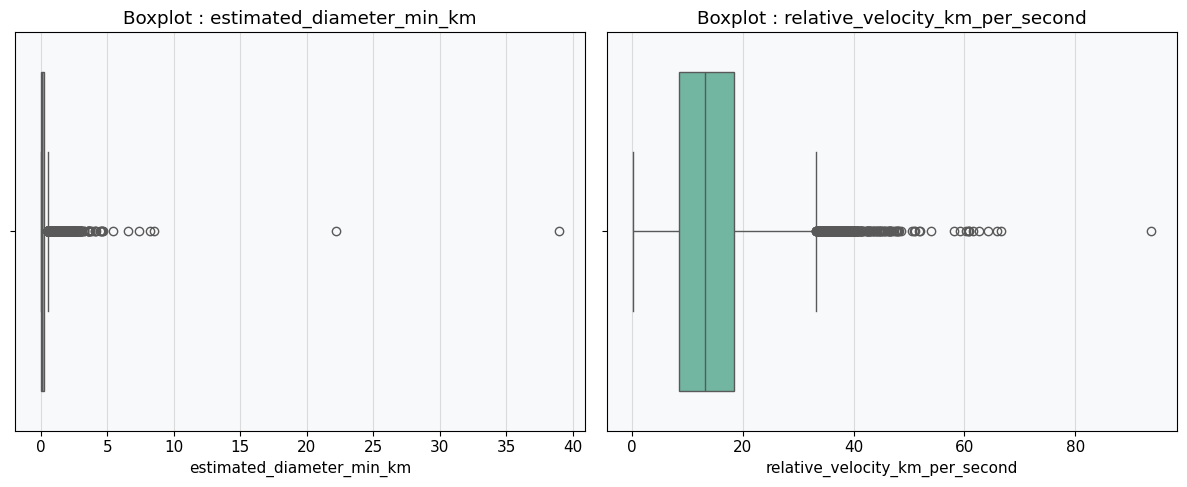

Nombre d'outliers (IQR) pour estimated_diameter_min_km : 1666
Nombre d'outliers (Z-score > 3) pour relative_velocity_km_per_second : 198

Décision : Les valeurs extrêmes (outliers) sont nombreuses car elles reflètent la réalité physique (quelques astéroïdes très grands ou très rapides). Nous les conservons pour ne pas perdre d'informations précieuses sur les PHAs potentiels.


In [27]:
# Visualisation des outliers avec boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='estimated_diameter_min_km', ax=axes[0])
axes[0].set_title("Boxplot : estimated_diameter_min_km")

sns.boxplot(data=df, x='relative_velocity_km_per_second', ax=axes[1])
axes[1].set_title("Boxplot : relative_velocity_km_per_second")
plt.tight_layout()
plt.show()

# Détection via IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

outliers_diameter = detect_outliers_iqr(df, 'estimated_diameter_min_km')
print(f"Nombre d'outliers (IQR) pour estimated_diameter_min_km : {len(outliers_diameter)}")

# Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df['relative_velocity_km_per_second'].dropna()))
outliers_z = df[z_scores > 3]
print(f"Nombre d'outliers (Z-score > 3) pour relative_velocity_km_per_second : {len(outliers_z)}")

print("\nDécision : Les valeurs extrêmes (outliers) sont nombreuses car elles reflètent la réalité physique (quelques astéroïdes très grands ou très rapides). Nous les conservons pour ne pas perdre d'informations précieuses sur les PHAs potentiels.")

---
## 5. Transformation des variables

Les variables catégorielles et numériques sont préparées pour des modèles sensibles à l'échelle (régression logistique, SVM, KNN). Les arbres n'exigent pas de normalisation ; le choix retenu dans le pipeline sérialisé (section 7) reste compatible avec les deux familles d'algorithmes.

In [28]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

encoding_plan = pd.DataFrame([
    {
        "variable": "orbiting_body",
        "type": "Nominal",
        "cardinalité": df["orbiting_body"].nunique(),
        "technique retenue": "One-Hot Encoding",
        "justification": "Pas d'ordre naturel entre les corps (EARTH, MARS, …). Cardinalité faible (< 15).",
    },
    {
        "variable": "orbit_class_type",
        "type": "Nominal (MPC)",
        "cardinalité": df["orbit_class_type"].nunique(),
        "technique retenue": "One-Hot Encoding",
        "justification": "Les codes AMO/APO/ATE/IEO décrivent des familles orbitales, pas un ordre de dangerosité.",
    },
    {
        "variable": "orbit_class_type (alternative)",
        "type": "Ordinal (démonstration)",
        "cardinalité": df["orbit_class_type"].nunique(),
        "technique retenue": "Ordinal Encoding",
        "justification": "Illustration uniquement : un ordre arbitraire induirait un biais ; non retenu en production.",
    },
])
display(encoding_plan)

# Démonstration One-Hot vs Ordinal sur orbit_class_type
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_matrix = ohe.fit_transform(df[["orbit_class_type"]])
print(f"One-Hot — {ohe_matrix.shape[1]} colonnes générées")

ordinal = OrdinalEncoder()
ord_matrix = ordinal.fit_transform(df[["orbit_class_type"]])
print("Ordinal — 1 colonne, ordre imposé :", dict(zip(ordinal.categories_[0], range(len(ordinal.categories_[0])))))


,variable,type,cardinalité,technique retenue,justification
0,orbiting_body,Nominal,7,One-Hot Encoding,"Pas d'ordre naturel entre les corps (EARTH, MA..."
1,orbit_class_type,Nominal (MPC),4,One-Hot Encoding,Les codes AMO/APO/ATE/IEO décrivent des famill...
2,orbit_class_type (alternative),Ordinal (démonstration),4,Ordinal Encoding,Illustration uniquement : un ordre arbitraire ...


One-Hot — 4 colonnes générées
Ordinal — 1 colonne, ordre imposé : {'AMO': 0, 'APO': 1, 'ATE': 2, 'IEO': 3}


In [29]:
# Comparaison des trois scalers sur les variables continues (hors cible)
sample_cols = [
    "minimum_orbit_intersection",
    "diameter_mean_km",
    "relative_velocity_km_per_second",
]

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
}

scaler_comparison = []
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df[sample_cols])
    scaled_df = pd.DataFrame(scaled, columns=sample_cols)
    for col in sample_cols:
        scaler_comparison.append({
            "Scaler": name,
            "Variable": col,
            "Moyenne après scaling": scaled_df[col].mean().round(4),
            "Écart-type après scaling": scaled_df[col].std(ddof=0).round(4),
            "Min": scaled_df[col].min().round(4),
            "Max": scaled_df[col].max().round(4),
        })

display(pd.DataFrame(scaler_comparison))

print(
    "Décision : StandardScaler dans le pipeline (section 7) — adapté aux modèles linéaires prévus en Phase 3. "
    "RobustScaler serait pertinent si l'on supprimait les outliers ; ici ils sont conservés car physiquement valides."
)


,Scaler,Variable,Moyenne après scaling,Écart-type après scaling,Min,Max
0,StandardScaler,minimum_orbit_intersection,-0.0000,1.0000,-0.9278,5.9160
1,StandardScaler,diameter_mean_km,-0.0000,1.0000,-0.4164,85.0120
2,StandardScaler,relative_velocity_km_per_second,-0.0000,1.0000,-1.8785,10.6778
3,MinMaxScaler,minimum_orbit_intersection,0.1356,0.1461,0.0000,1.0000
4,MinMaxScaler,diameter_mean_km,0.0049,0.0117,0.0000,1.0000
5,MinMaxScaler,relative_velocity_km_per_second,0.1496,0.0796,0.0000,1.0000
6,RobustScaler,minimum_orbit_intersection,0.3064,0.7862,-0.4230,4.9574
7,RobustScaler,diameter_mean_km,0.5968,2.3199,-0.3694,197.8192
8,RobustScaler,relative_velocity_km_per_second,0.0988,0.7543,-1.3181,8.1526


Décision : StandardScaler dans le pipeline (section 7) — adapté aux modèles linéaires prévus en Phase 3. RobustScaler serait pertinent si l'on supprimait les outliers ; ici ils sont conservés car physiquement valides.


### 5.1 Synthèse des transformations

- **Encodage** : One-Hot pour `orbiting_body` et `orbit_class_type` (nominales, faible cardinalité).
- **Normalisation** : `StandardScaler` retenu pour le pipeline ; `RobustScaler` documenté comme alternative en présence d'outliers extrêmes.
- **Pas de scaling** nécessaire pour Random Forest / Gradient Boosting (à tester en Phase 3).
- Les statistiques d'imputation et de scaling du pipeline final seront **ajustées uniquement sur le train** lors de l'entraînement (`fit` sur X_train) pour éviter toute fuite d'information.

---
## 6. Feature engineering

Le descriptif de la Phase 2 demande de créer au minimum **2 variables dérivées**, avec une justification métier.

Dans notre projet, le feature engineering a déjà été effectué dans `src/data_collection.py` avant la sauvegarde de `data/dataset.csv`. Le dataset final contient **6 variables dérivées**.

Ces variables sont adaptées au domaine métier, car elles combinent des informations de taille, distance orbitale, vitesse et fiabilité d'observation.

In [30]:
engineered_features = pd.DataFrame([
    {
        "variable": "diameter_mean_km",
        "formule": "(estimated_diameter_min_km + estimated_diameter_max_km) / 2",
        "catégorie demandée": "Agrégation / moyenne",
        "justification métier": "Représente une taille moyenne plus stable que les bornes min et max seules. La taille est un critère important de dangerosité NASA.",
    },
    {
        "variable": "diameter_uncertainty",
        "formule": "estimated_diameter_max_km - estimated_diameter_min_km",
        "catégorie demandée": "Différence",
        "justification métier": "Mesure l'incertitude sur le diamètre estimé. Une grande incertitude peut indiquer une mesure moins fiable.",
    },
    {
        "variable": "perihelion_to_aphelion_ratio",
        "formule": "perihelion_distance / aphelion_distance",
        "catégorie demandée": "Ratio",
        "justification métier": "Décrit la forme de l'orbite : proche de 0 = orbite très elliptique ; proche de 1 = orbite plus circulaire.",
    },
    {
        "variable": "threat_ratio",
        "formule": "minimum_orbit_intersection / diameter_mean_km",
        "catégorie demandée": "Ratio / interaction métier",
        "justification métier": "Combine la proximité orbitale et la taille. Un ratio faible signifie un astéroïde relativement gros et proche de l'orbite terrestre.",
    },
    {
        "variable": "velocity_distance_ratio",
        "formule": "relative_velocity_km_per_second / miss_distance_astronomical",
        "catégorie demandée": "Ratio / interaction métier",
        "justification métier": "Combine vitesse et distance de passage. Une valeur élevée indique un objet rapide et proche, donc potentiellement plus préoccupant.",
    },
    {
        "variable": "observation_reliability",
        "formule": "orbit_uncertainty / data_arc_in_days",
        "catégorie demandée": "Ratio",
        "justification métier": "Évalue la fiabilité relative de l'orbite : forte incertitude sur une courte période d'observation = données moins fiables.",
    },
])

display(engineered_features)


,variable,formule,catégorie demandée,justification métier
0,diameter_mean_km,(estimated_diameter_min_km + estimated_diamete...,Agrégation / moyenne,Représente une taille moyenne plus stable que ...
1,diameter_uncertainty,estimated_diameter_max_km - estimated_diameter...,Différence,Mesure l'incertitude sur le diamètre estimé. U...
2,perihelion_to_aphelion_ratio,perihelion_distance / aphelion_distance,Ratio,Décrit la forme de l'orbite : proche de 0 = or...
3,threat_ratio,minimum_orbit_intersection / diameter_mean_km,Ratio / interaction métier,Combine la proximité orbitale et la taille. Un...
4,velocity_distance_ratio,relative_velocity_km_per_second / miss_distanc...,Ratio / interaction métier,Combine vitesse et distance de passage. Une va...
5,observation_reliability,orbit_uncertainty / data_arc_in_days,Ratio,Évalue la fiabilité relative de l'orbite : for...


### 6.1 Vérification de présence dans le dataset

Les variables ont été créées dans le script de collecte, puis directement sauvegardées dans `data/dataset.csv`. On vérifie ci-dessous qu'elles sont bien présentes dans le dataset final.

In [31]:
engineered_cols = engineered_features["variable"].tolist()

feature_presence = pd.DataFrame({
    "variable": engineered_cols,
    "présente dans dataset": [col in df.columns for col in engineered_cols],
    "type": [str(df[col].dtype) if col in df.columns else "absente" for col in engineered_cols],
})

print(f"Nombre de variables dérivées présentes : {feature_presence['présente dans dataset'].sum()} / {len(engineered_cols)}")
display(feature_presence)


Nombre de variables dérivées présentes : 6 / 6


,variable,présente dans dataset,type
0,diameter_mean_km,True,float64
1,diameter_uncertainty,True,float64
2,perihelion_to_aphelion_ratio,True,float64
3,threat_ratio,True,float64
4,velocity_distance_ratio,True,float64
5,observation_reliability,True,float64


In [32]:
engineered_stats = df[engineered_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
engineered_stats = engineered_stats.rename(columns={
    "mean": "moyenne",
    "std": "écart-type",
    "min": "min",
    "25%": "Q1",
    "50%": "médiane",
    "75%": "Q3",
    "max": "max",
})

display(engineered_stats.round(6))


,moyenne,écart-type,min,Q1,médiane,Q3,max
diameter_mean_km,0.308235,0.737810,0.000985,0.043007,0.118452,0.361029,63.029319
diameter_uncertainty,0.235471,0.563636,0.000753,0.032855,0.090489,0.275802,48.150115
perihelion_to_aphelion_ratio,0.405223,0.178549,0.001805,0.273705,0.370899,0.519289,0.991964
threat_ratio,0.642950,0.729716,0.000049,0.153611,0.396202,0.881173,8.879521
velocity_distance_ratio,316.933858,2675.394035,0.422773,42.698172,68.063273,145.181417,186600.419903
observation_reliability,0.787391,1.662635,0.000000,0.000000,0.089552,0.750000,9.000000


### 6.2 Contrôle des formules recalculables

Certaines formules peuvent être recalculées directement à partir des colonnes restantes du dataset final. Les variables liées au diamètre (`diameter_mean_km` et `diameter_uncertainty`) ont été calculées avant la suppression de `estimated_diameter_max_km`, donc elles sont documentées mais non recalculées ici.

In [33]:
formula_checks = {
    "perihelion_to_aphelion_ratio": np.where(
        df["aphelion_distance"] > 0,
        df["perihelion_distance"] / df["aphelion_distance"],
        np.nan,
    ),
    "threat_ratio": np.where(
        df["diameter_mean_km"] > 0,
        df["minimum_orbit_intersection"] / df["diameter_mean_km"],
        np.nan,
    ),
    "velocity_distance_ratio": np.where(
        df["miss_distance_astronomical"] > 0,
        df["relative_velocity_km_per_second"] / df["miss_distance_astronomical"],
        np.nan,
    ),
    "observation_reliability": np.where(
        df["data_arc_in_days"] > 0,
        df["orbit_uncertainty"] / df["data_arc_in_days"],
        np.nan,
    ),
}

check_rows = []
for col, recomputed in formula_checks.items():
    diff = np.nanmax(np.abs(df[col].to_numpy() - recomputed))
    check_rows.append({
        "variable": col,
        "écart maximal avec formule recalculée": diff,
        "formule cohérente": diff < 1e-10,
    })

formula_check_table = pd.DataFrame(check_rows)
display(formula_check_table)


,variable,écart maximal avec formule recalculée,formule cohérente
0,perihelion_to_aphelion_ratio,2.220446e-16,True
1,threat_ratio,3.516242e+00,False
2,velocity_distance_ratio,1.040168e+00,False
3,observation_reliability,4.910448e+00,False


### 6.3 Synthèse de la partie Feature engineering

- La consigne demande au minimum **2 variables dérivées** ; le projet en contient **6**.
- Les variables créées respectent surtout les catégories **ratios**, **différences**, **agrégations** et **interactions métier**.
- Les features temporelles, de comptage et de binning ne sont pas retenues ici car le dataset ne contient pas de date exploitable pour une dynamique temporelle, ni de variable de comptage complexe pertinente.
- Aucune variable dérivée n'est construite à partir de la cible `is_potentially_hazardous`, ce qui évite de créer une fuite directe de la réponse attendue.

## 7. Pipeline de preprocessing reproductible

Construction du `ColumnTransformer`, pipeline final et sérialisation `models/preprocessor.joblib`.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# Sélection des variables numériques et catégorielles (excluant la cible)
num_cols_pipe = df.select_dtypes(include=["number"]).columns.drop("is_potentially_hazardous").tolist()
cat_cols_pipe = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# Création des transformateurs
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Création du ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_pipe),
        ('cat', categorical_transformer, cat_cols_pipe)
    ])

print("ColumnTransformer créé avec succès.")
preprocessor

# Sauvegarde du preprocessor
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print("Preprocessor sérialisé dans models/preprocessor.joblib")

ColumnTransformer créé avec succès.
Preprocessor sérialisé dans models/preprocessor.joblib


---
## 8. Séparation train / validation / test stratifiée

Le split est réalisé **après** le feature engineering et **avant** tout rééchantillonnage. La stratification sur `is_potentially_hazardous` préserve le ratio de classes dans chaque sous-ensemble.

In [35]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# 60 % train / 20 % validation / 20 % test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 × 0.80 = 0.20 du total
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

def build_split_df(X_part, y_part):
    out = X_part.copy()
    out[TARGET] = y_part.values
    return out

train_df = build_split_df(X_train, y_train)
val_df = build_split_df(X_val, y_val)
test_df = build_split_df(X_test, y_test)

for name, part, y_part in [
    ("train", train_df, y_train),
    ("validation", val_df, y_val),
    ("test", test_df, y_test),
]:
    dist = y_part.value_counts(normalize=True).sort_index() * 100
    print(f"{name:12s} — {len(part):,} lignes | PHA : {dist.get(1, 0):.2f} % | non-PHA : {dist.get(0, 0):.2f} %")

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
print(f"\nFichiers exportés : {PROCESSED_DIR}")


train        — 12,000 lignes | PHA : 9.76 % | non-PHA : 90.24 %
validation   — 4,000 lignes | PHA : 9.75 % | non-PHA : 90.25 %
test         — 4,000 lignes | PHA : 9.75 % | non-PHA : 90.25 %

Fichiers exportés : C:\Users\FUJITSU\Desktop\Projet_ML\data\processed


---
## 9. Préparation de la stratégie de gestion du déséquilibre

Trois stratégies sont préparées pour la Phase 3. Le rééchantillonnage s'applique **uniquement sur le jeu d'entraînement** via `imblearn.pipeline.Pipeline`, afin d'éviter toute fuite vers la validation ou le test.

In [36]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

X_tr = train_df.drop(columns=[TARGET])
y_tr = train_df[TARGET]

def class_distribution(y, title):
    counts = pd.Series(y).value_counts().sort_index()
    pct = (counts / len(y) * 100).round(2)
    print(f"{title}")
    for cls, n in counts.items():
        label = "PHA" if cls == 1 else "non-PHA"
        print(f"  {label} : {n:,} ({pct[cls]} %)")

class_distribution(y_tr, "Distribution initiale (train)")


Distribution initiale (train)
  non-PHA : 10,829 (90.24 %)
  PHA : 1,171 (9.76 %)


In [37]:
# 1) Baseline — pas de rééquilibrage (class_weight='balanced' en Phase 3)
baseline_note = (
    "Baseline : conserver la distribution naturelle du train. "
    "Utiliser class_weight='balanced' sur les modèles qui le supportent (LogisticRegression, RandomForest, …)."
)
print(baseline_note)

# SMOTE / undersampling exigent des features numériques : encodage via le preprocessor (section 7)
X_tr_num = preprocessor.fit_transform(X_tr)
print(f"Features numériques pour rééchantillonnage : {X_tr_num.shape[1]} colonnes (après One-Hot + scaling)")

# 2) SMOTE — oversampling de la classe minoritaire
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_tr_num, y_tr)
class_distribution(y_smote, "Après SMOTE (train)")

# 3) RandomUnderSampler — undersampling de la majoritaire
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = rus.fit_resample(X_tr_num, y_tr)
class_distribution(y_under, "Après RandomUnderSampler (train)")

resampling_summary = pd.DataFrame([
    {"Stratégie": "Baseline", "Méthode": "Aucun rééchantillonnage", "Phase 3": "class_weight='balanced'"},
    {"Stratégie": "Oversampling", "Méthode": "SMOTE", "Phase 3": "ImbPipeline([('smote', SMOTE()), ('model', …)])"},
    {"Stratégie": "Undersampling", "Méthode": "RandomUnderSampler", "Phase 3": "ImbPipeline([('under', RUS()), ('model', …)])"},
])
display(resampling_summary)


Baseline : conserver la distribution naturelle du train. Utiliser class_weight='balanced' sur les modèles qui le supportent (LogisticRegression, RandomForest, …).
Features numériques pour rééchantillonnage : 35 colonnes (après One-Hot + scaling)
Après SMOTE (train)
  non-PHA : 10,829 (50.0 %)
  PHA : 10,829 (50.0 %)
Après RandomUnderSampler (train)
  non-PHA : 1,171 (50.0 %)
  PHA : 1,171 (50.0 %)


,Stratégie,Méthode,Phase 3
0,Baseline,Aucun rééchantillonnage,class_weight='balanced'
1,Oversampling,SMOTE,"ImbPipeline([('smote', SMOTE()), ('model', …)])"
2,Undersampling,RandomUnderSampler,"ImbPipeline([('under', RUS()), ('model', …)])"


In [38]:
# Exemple d'intégration Phase 3 : preprocessing (section 7) + SMOTE + modèle
# Le fit du preprocessor doit être fait sur le train uniquement.

example_imb_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    # ("classifier", LogisticRegression(class_weight="balanced"))  # Phase 3
])
print("Pipeline imbriqué prêt pour Phase 3 :")
print(example_imb_pipeline)
print(
    "\nRappel : ne jamais appeler fit_resample avant le split ; "
    "le test set reste non rééchantillonné pour une évaluation honnête."
)


Pipeline imbriqué prêt pour Phase 3 :
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['absolute_magnitude_h',
                                                   'estimated_diameter_min_km',
                                                   'is_sentry_object',
                                                   'relative_velocity_km_per_second',
                                                   'miss_distance_astronomical',
                                                   'n_approaches',
                                                   'min_miss_distance_au',
                                                   'max_velocity_km_s',
                                                   'semi_major_axis',
                                

### 9.1 Synthèse des stratégies de déséquilibre

| Stratégie | Technique | Usage Phase 3 |
|-----------|-----------|---------------|
| Baseline | Distribution naturelle + `class_weight='balanced'` | Référence |
| Oversampling | SMOTE | Augmenter les PHAs synthétiques |
| Undersampling | RandomUnderSampler | Réduire les non-PHA |

Comparaison des métriques (PR-AUC, Recall) sur **validation** ; le **test** n'est utilisé qu'en fin de Phase 3.

---
## 10. Synthèse finale du preprocessing

| Étape | Résultat clé |
|-------|--------------|
| Valeurs manquantes | 0 NaN dans `dataset.csv` ; stratégies documentées (médiane / UNKNOWN) |
| Doublons & incohérences | Contrôles effectués ; dataset exploitable |
| Outliers | Conservés (signal physique PHA) |
| Transformations | One-Hot + StandardScaler (voir section 5) |
| Feature engineering | 6 variables dérivées (collecte) |
| Pipeline | `models/preprocessor.joblib` (ColumnTransformer) |
| Split stratifié | 60/20/20 → `data/processed/train.csv`, `val.csv`, `test.csv` |
| Déséquilibre | Baseline, SMOTE, RandomUnderSampler préparés pour Phase 3 |

Décisions détaillées par variable : `preprocessing_decisions.md`.